# tr_diffusion — inference / denoising test

Runs the trained **conditional DDIM** denoiser (and the baseline, if trained) on held-out
frames of `212_Wunderkerze2` and compares them.

**Key point (measured below):** this is a *denoiser*, not an unconditional generator. Full
DDIM from pure noise (`start_step=0`) collapses (≈12 dB); the right mode is a **truncated
start** — noise the measured frame to a moderate timestep and denoise back down
(`start_step` late in the schedule) — which reaches ≈30 dB, well above the noisy input
(≈24.6 dB). A single-step `pred_x0` is already ≈31 dB.

Evaluation uses the **extra-noise** regime: extra Poisson noise is injected into the input
and the original measured frame is a strictly-lower-noise **pseudo-reference**, so PSNR/SSIM
are meaningful. Inference resamples the N2V blind-spot mask on every DDIM step.

In [1]:
%matplotlib inline
from pathlib import Path
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('/myhome/sdate')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
 
from sdate.tr_diffusion.data import TimeResolvedFrameDataset
from sdate.tr_diffusion.load import load_denoiser
from sdate.tr_diffusion.pipeline import denoise_frames, denoise_frames_baseline, build_ddim_scheduler
from sdate.tr_diffusion.profiles import DatasetProfile
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Change these two lines to point the whole notebook at a different acquisition/run. ---
PROFILE = 'ag10_c1mm'         # or 'wunderkerze2', 'asc_thixo', or a profile JSON path
EXP_NAME = 'ag10_dose005'      # matches --exp_name used in tr_diffusion.train
prof = DatasetProfile.load(PROFILE)

CKPT_DIR = PROJECT_ROOT / 'checkpoints'
DIFFUSION_CKPT = CKPT_DIR / f'tr_denoise_diffusion_{EXP_NAME}.pt'
BASELINE_CKPT  = CKPT_DIR / f'tr_denoise_baseline_{EXP_NAME}.pt'
print('device:', device, '| profile:', prof.name)

device: cuda | profile: 043_AG10_C1mm_0s


## 1. Load the trained model(s)

In [2]:
model, cfg = load_denoiser(DIFFUSION_CKPT, device=device)
print('diffusion loaded:', DIFFUSION_CKPT.name, '|', f'{sum(p.numel() for p in model.parameters()):,} params')
print('config:', {k: cfg[k] for k in ('mode','k','crop','in_channels','norm_min','norm_max','extra_noise_dose')})

baseline = None
if BASELINE_CKPT.exists():
    baseline, _ = load_denoiser(BASELINE_CKPT, device=device)
    print('baseline loaded:', BASELINE_CKPT.name)
else:
    print('baseline checkpoint not found (skipping baseline) ->', BASELINE_CKPT.name)

# Geometry: prefer what's recorded in the checkpoint config (ground truth for how the
# model was trained); fall back to the profile (older checkpoints predate these fields).
DEG_PER_FRAME = cfg.get('deg_per_frame') or prof.deg_per_frame
AXIS_COL = cfg.get('axis_col') or prof.rot_axis_col
print('deg/frame:', DEG_PER_FRAME, '| axis col:', AXIS_COL)

diffusion loaded: tr_denoise_diffusion_ag10_dose005.pt | 28,530,241 params
config: {'mode': 'diffusion', 'k': 1, 'crop': [256, 480], 'in_channels': 6, 'norm_min': 488.4211120605469, 'norm_max': 1472.22216796875, 'extra_noise_dose': 0.05}


baseline loaded: tr_denoise_baseline_ag10_dose005.pt
deg/frame: 0.900452 | axis col: 252.3


## 2. Held-out evaluation samples (extra-noise regime)

In [3]:
K, CROP, NORM = int(cfg['k']), tuple(cfg['crop']), (cfg['norm_min'], cfg['norm_max'])
DR = NORM[1] - NORM[0]
DOSE = 0.05   # match the training dose (very heavy noise)
MM = prof.memmap_path

# Held-out eval range: offset into the profile's frame range so it doesn't start
# exactly at the training range's edge (context margin effects).
_span = prof.frame_end - prof.frame_start
EVAL_START = prof.frame_start + int(0.17 * _span)
EVAL_END = prof.frame_end

ds = TimeResolvedFrameDataset(
    mov_path=cfg['mov'], memmap_path=MM, k=K, frame_start=EVAL_START, frame_end=EVAL_END,
    crop=CROP, norm_range=NORM, extra_noise_dose=DOSE, max_samples=64, seed=7,
    axis_col=AXIS_COL, deg_per_frame=DEG_PER_FRAME,
)
N = 3
items = [ds[i] for i in range(N)]
central   = torch.stack([it['central'] for it in items]).to(device)     # noisy input
context   = torch.stack([it['context'] for it in items]).to(device)
reference = torch.stack([it['reference'] for it in items]).to(device)    # lower-noise ref
print('eval:', len(ds), 'samples | dose', DOSE, '| central', tuple(central.shape))

def to_counts(x):
    return ((x.detach().float().cpu().clamp(-1, 1) + 1) * 0.5 * DR + NORM[0]).numpy()[:, 0]
def scores(pred_c, ref_c):
    return (float(np.mean([psnr(r, p, data_range=DR) for p, r in zip(pred_c, ref_c)])),
            float(np.mean([ssim(r, p, data_range=DR) for p, r in zip(pred_c, ref_c)])))

ref_c, in_c = to_counts(reference), to_counts(central)

eval: 64 samples | dose 0.05 | central (3, 1, 256, 480)


## 2b. Visualize this dataset

Whatever `PROFILE` is set to above, this shows the raw held-out samples actually being
fed to the model: the noisy central frame, its rotation/temporal context taps, and the
lower-noise reference — in physical counts (not just normalized [-1,1]).

profile: 043_AG10_C1mm_0s  |  crop: (256, 480)  |  context channels: ['rot-1', 'rot+1', 'tmp-1', 'tmp+1']
norm range (counts): [488.4, 1472.2]


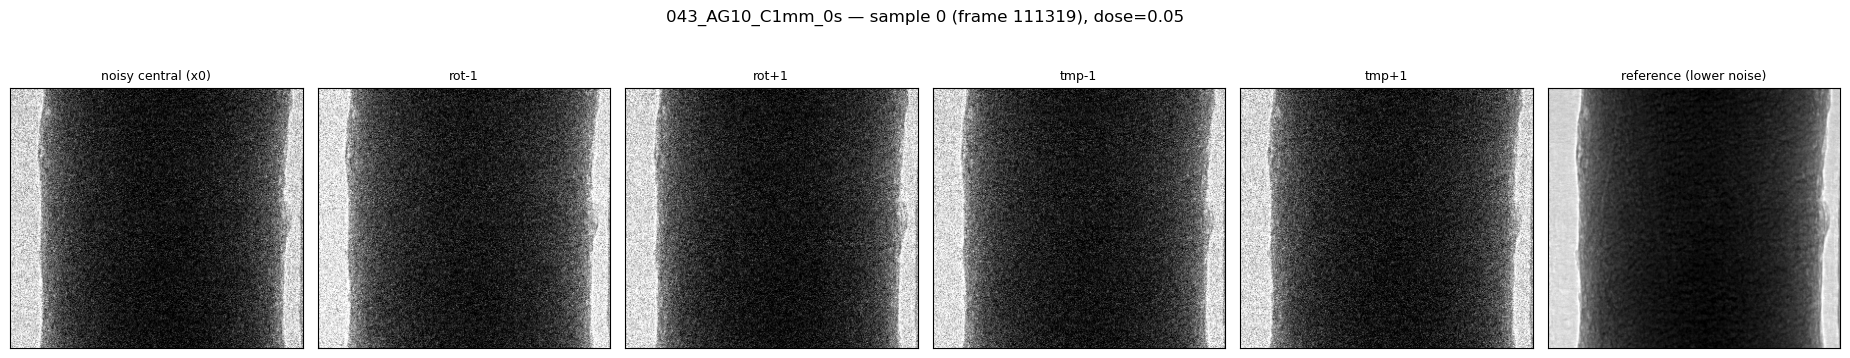

noisy input : PSNR 19.04 dB  SSIM 0.198  (vs reference, no-op)


In [4]:
ctx_names = [t.name for t in ds.layout] if ds.layout else []
print(f'profile: {prof.name}  |  crop: {CROP}  |  context channels: {ctx_names or "(k=0, none)"}')
print(f'norm range (counts): [{NORM[0]:.1f}, {NORM[1]:.1f}]')

i = 0
row_labels = ['noisy central (x0)'] + ctx_names + ['reference (lower noise)']
row_imgs = [in_c[i]] + [to_counts(context[i:i+1, j:j+1])[0] for j in range(context.shape[1])] + [ref_c[i]]
n = len(row_imgs)
fig, axes = plt.subplots(1, n, figsize=(3.1 * n, 3.4))
vmin, vmax = NORM
for ax, img, lbl in zip(axes, row_imgs, row_labels):
    ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(lbl, fontsize=9); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f'{prof.name} — sample {i} (frame {int(items[i]["frame_index"])}), dose={DOSE}', y=1.04)
plt.tight_layout(); plt.show()

print(f'noisy input : PSNR {scores(in_c, ref_c)[0]:.2f} dB  SSIM {scores(in_c, ref_c)[1]:.3f}  (vs reference, no-op)')

In [5]:
import lovely_tensors as lt
lt.monkey_patch()
context, central

(tensor[3, 4, 256, 480] n=1474560 (5.62 MiB) x∈[-1.708 |▁▅█▃▂▂▁▁▁ | 2.520] μ=-0.418 σ=0.636 cuda:0,
 tensor[3, 1, 256, 480] n=368640 (1.41 MiB) x∈[-1.627 |▁▇█▃▂▂▂▁▁ | 2.317] μ=-0.443 σ=0.622 cuda:0)

## 3. `start_step` sweep — pick the inference mode

`start_step` indexes into the DDIM schedule. `0` = generate from pure noise (wrong for a
denoiser); larger = start from the measurement noised less, i.e. lighter denoising. The
sweep shows the characteristic collapse at `0` and a broad optimum late in the schedule.

  start_step= 5 -> PSNR 18.92 dB


  start_step=10 -> PSNR 19.51 dB


  start_step=15 -> PSNR 19.62 dB


  start_step=20 -> PSNR 19.65 dB


  start_step=25 -> PSNR 19.68 dB


  start_step=30 -> PSNR 19.72 dB


  start_step=35 -> PSNR 19.73 dB


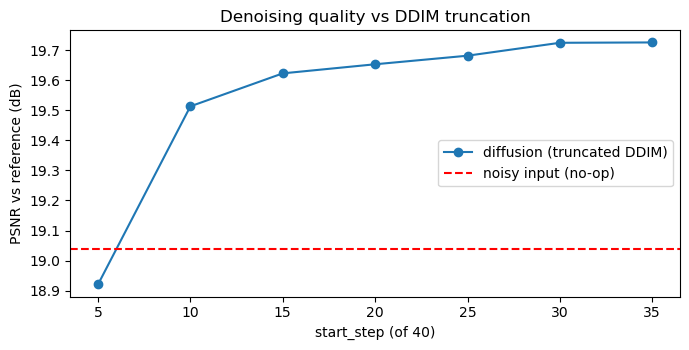

best start_step = 35


In [6]:
scheduler = build_ddim_scheduler(num_train_timesteps=1000)
NUM_STEPS = 40
sweep = [5, 10, 15, 20, 25, 30, 35]
psnrs = []
for ss in sweep:
    g = torch.Generator(device=device).manual_seed(0)
    out = denoise_frames(model, central, context, scheduler=scheduler,
                         num_inference_steps=NUM_STEPS, start_step=ss,
                         ratio=cfg['n2v_ratio'], window=cfg['n2v_window'], generator=g)
    p, _ = scores(to_counts(out), ref_c)
    psnrs.append(p); print(f'  start_step={ss:2d} -> PSNR {p:.2f} dB')

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(sweep, psnrs, 'o-', label='diffusion (truncated DDIM)')
ax.axhline(scores(in_c, ref_c)[0], color='r', ls='--', label='noisy input (no-op)')
ax.set_xlabel('start_step (of %d)' % NUM_STEPS); ax.set_ylabel('PSNR vs reference (dB)')
ax.set_title('Denoising quality vs DDIM truncation'); ax.legend(); plt.tight_layout(); plt.show()

START_STEP = sweep[int(np.argmax(psnrs))]
print('best start_step =', START_STEP)

## 4. Run inference at the chosen mode + metrics

Reports the no-op `PSNR(noisy, reference)` — any denoiser must beat it.

In [7]:
g = torch.Generator(device=device).manual_seed(0)
den_diff = denoise_frames(model, central, context, scheduler=scheduler,
                          num_inference_steps=NUM_STEPS, start_step=START_STEP,
                          ratio=cfg['n2v_ratio'], window=cfg['n2v_window'], generator=g)
den_base = denoise_frames_baseline(baseline, central, context) if baseline is not None else None

diff_c = to_counts(den_diff)
base_c = to_counts(den_base) if den_base is not None else None

print(f'{"":16s} {"PSNR(dB)":>9s} {"SSIM":>7s}')
p, s = scores(in_c, ref_c);   print(f'{"noisy input":16s} {p:9.2f} {s:7.3f}   <- no-op baseline')
p, s = scores(diff_c, ref_c); print(f'{"diffusion":16s} {p:9.2f} {s:7.3f}   (start_step={START_STEP})')
if base_c is not None:
    p, s = scores(base_c, ref_c); print(f'{"baseline UNet":16s} {p:9.2f} {s:7.3f}')

                  PSNR(dB)    SSIM
noisy input          19.04   0.198   <- no-op baseline
diffusion            19.73   0.205   (start_step=35)
baseline UNet        34.55   0.868


## 5. Visual comparison

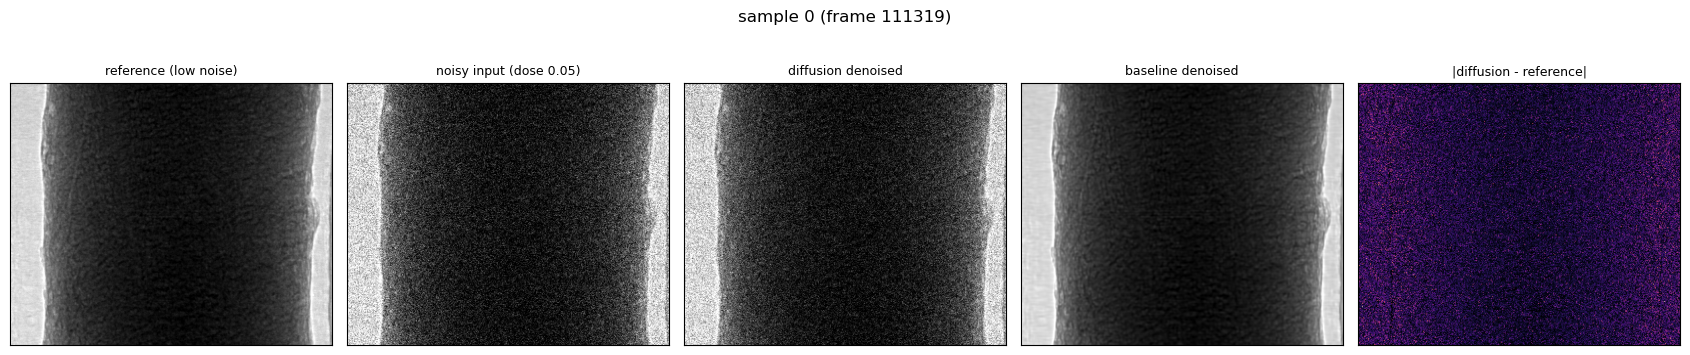

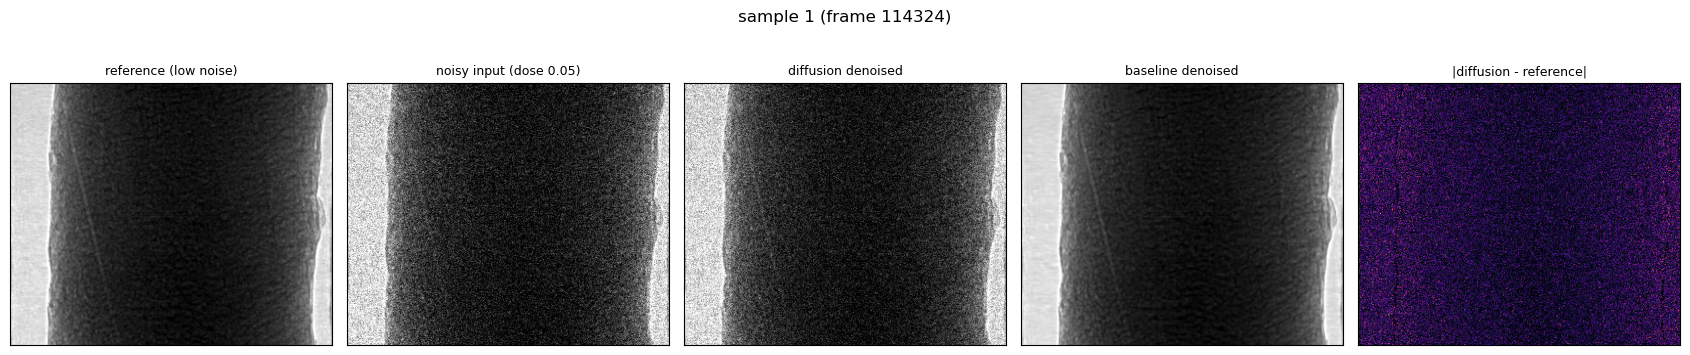

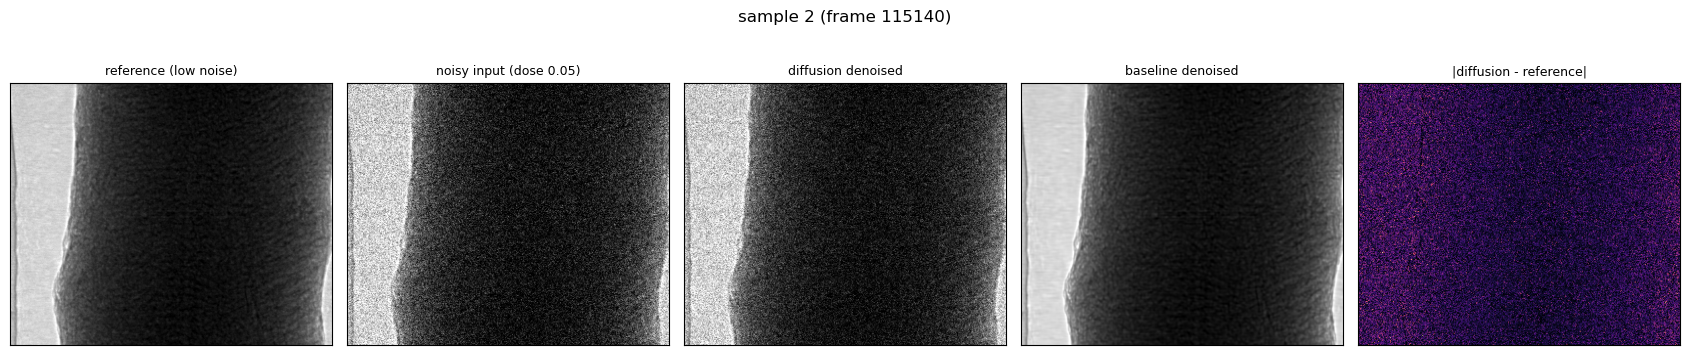

In [8]:
ncol = 5 if base_c is not None else 4
lo, hi = NORM
for i in range(N):
    fig, axes = plt.subplots(1, ncol, figsize=(3.4 * ncol, 3.4))
    panels = [('reference (low noise)', ref_c[i]),
              (f'noisy input (dose {DOSE})', in_c[i]),
              ('diffusion denoised', diff_c[i])]
    if base_c is not None:
        panels.append(('baseline denoised', base_c[i]))
    for ax, (title, img) in zip(axes, panels):
        ax.imshow(img, cmap='gray', vmin=lo, vmax=hi, aspect='auto')
        ax.set_title(title, fontsize=9); ax.set_xticks([]); ax.set_yticks([])
    axes[-1].imshow(np.abs(diff_c[i] - ref_c[i]), cmap='magma', aspect='auto')
    axes[-1].set_title('|diffusion - reference|', fontsize=9)
    axes[-1].set_xticks([]); axes[-1].set_yticks([])
    fig.suptitle(f'sample {i} (frame {int(items[i]["frame_index"])})', y=1.03)
    plt.tight_layout(); plt.show()

## 6. Single-step `pred_x0` (cheapest denoiser)

Noise a frame to timestep `t`, one forward pass, read off `pred_x0`. Often already the
strongest result here — a useful diagnostic of what the network learned.

    t  pred_x0 PSNR


  200         26.37


  400         30.92


  500         32.05


  600         31.63


  800         24.82


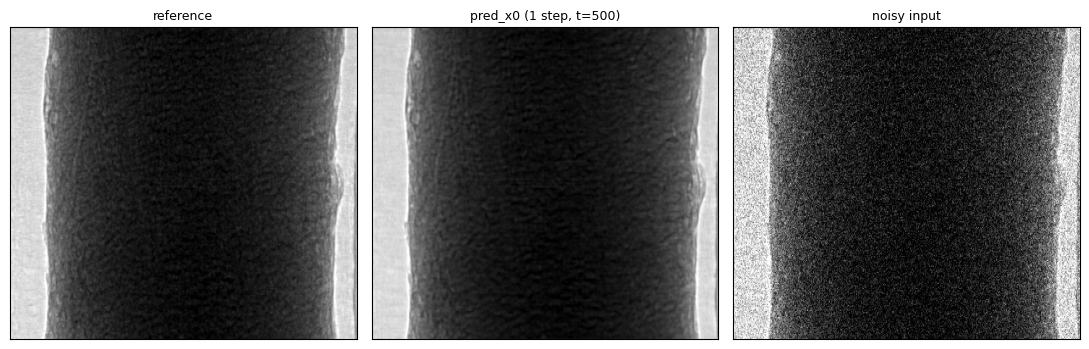

In [9]:
from diffusers import DDPMScheduler
from sdate.tr_diffusion.n2v import blind_spot_corrupt

sched = DDPMScheduler(num_train_timesteps=1000)
acp = sched.alphas_cumprod.to(device)
print(f'{"t":>5s} {"pred_x0 PSNR":>13s}')
best = None
for t in (200, 400, 500, 600, 800):
    noise = torch.randn_like(central)
    x_t = sched.add_noise(central, noise, torch.full((N,), t, device=device))
    corr, _ = blind_spot_corrupt(central, ratio=cfg['n2v_ratio'], window=cfg['n2v_window'])
    with torch.no_grad():
        eps = model(torch.cat([x_t, corr, context], 1), timestep=torch.full((N,), t, device=device),
                    class_labels=torch.ones(N, device=device, dtype=torch.long), return_dict=False)[0]
    px0 = (x_t - (1 - acp[t]) ** 0.5 * eps) / acp[t] ** 0.5
    p, _ = scores(to_counts(px0), ref_c); print(f'{t:5d} {p:13.2f}')
    if best is None or t == 500: best = (t, to_counts(px0))

t0, px0_c = best
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for ax, (ttl, im) in zip(axes, [('reference', ref_c[0]),
                                (f'pred_x0 (1 step, t={t0})', px0_c[0]),
                                ('noisy input', in_c[0])]):
    ax.imshow(im, cmap='gray', vmin=lo, vmax=hi, aspect='auto')
    ax.set_title(ttl, fontsize=9); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 7. Sample-averaging — the MMSE estimator

Each stochastic sample is a draw from the model's posterior `p(x0 | y)`. A single draw has
the right *texture* but sample-specific error; the **posterior mean** `E[x0|y]` is what
minimizes MSE, and averaging `B` independent samples is a Monte Carlo estimate of it.
Diversity here comes from (i) independent initial noise per sample and (ii) an independent
per-step blind-spot mask — so even the deterministic `eta=0` DDIM gives distinct samples
from a truncated start.

We sweep `B` and, for each, average `B` samples and score against the reference.

In [10]:
from sdate.tr_diffusion.pipeline import denoise_frames_ensemble

# A larger held-out batch for a more stable curve.
M = 8
mitems = [ds[i] for i in range(M)]
mcentral = torch.stack([it['central'] for it in mitems]).to(device)
mcontext = torch.stack([it['context'] for it in mitems]).to(device)
mref_c   = to_counts(torch.stack([it['reference'] for it in mitems]).to(device))
min_c    = to_counts(mcentral)

Bmax = 128
g = torch.Generator(device=device).manual_seed(1)
# Draw Bmax samples once, then average PROGRESSIVELY over prefixes (cheap + consistent).
mean, samples = denoise_frames_ensemble(
    model, mcentral, mcontext, num_samples=Bmax, scheduler=scheduler,
    num_inference_steps=NUM_STEPS, start_step=START_STEP,
    ratio=cfg['n2v_ratio'], window=cfg['n2v_window'], generator=g,
)  # samples: (M, Bmax, 1, H, W)

Bs = [16, 32, 64, Bmax]
avg_psnr, avg_ssim, single_psnr = [], [], []
for B in Bs:
    avg_c = to_counts(samples[:, :B].mean(dim=1))           # average of first B samples
    p, s = scores(avg_c, mref_c); avg_psnr.append(p); avg_ssim.append(s)
    # mean single-sample score over those B draws (spread reference)
    sp = np.mean([scores(to_counts(samples[:, j]), mref_c)[0] for j in range(B)])
    single_psnr.append(sp)
    print(f'B={B:2d}:  avg PSNR {p:5.2f}  SSIM {s:.3f}   | mean single-sample PSNR {sp:5.2f}')

noop_p = scores(min_c, mref_c)[0]
print(f'\nno-op (noisy input) PSNR {noop_p:.2f}')

B=16:  avg PSNR 23.51  SSIM 0.392   | mean single-sample PSNR 19.75


B=32:  avg PSNR 23.72  SSIM 0.405   | mean single-sample PSNR 19.75


B=64:  avg PSNR 23.82  SSIM 0.412   | mean single-sample PSNR 19.75


B=128:  avg PSNR 23.87  SSIM 0.416   | mean single-sample PSNR 19.75

no-op (noisy input) PSNR 19.07


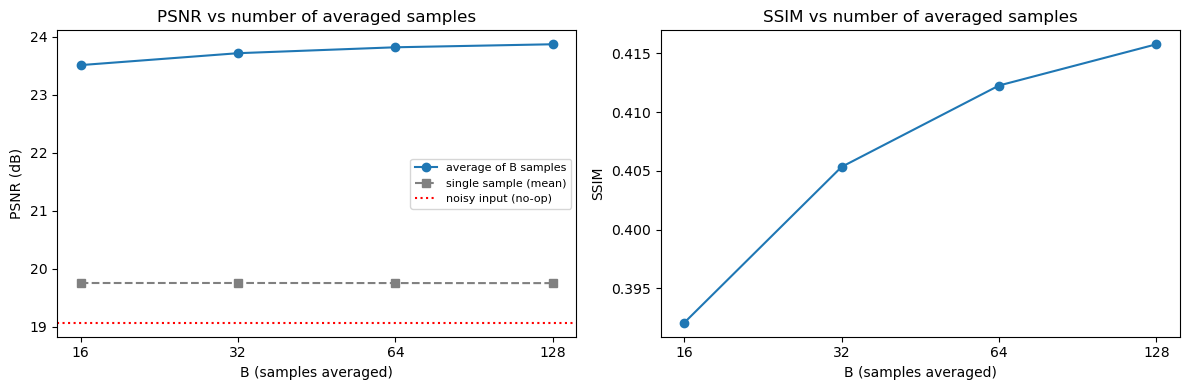

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(Bs, avg_psnr, 'o-', label='average of B samples')
ax[0].plot(Bs, single_psnr, 's--', color='gray', label='single sample (mean)')
ax[0].axhline(noop_p, color='r', ls=':', label='noisy input (no-op)')
ax[0].set_xscale('log', base=2); ax[0].set_xticks(Bs); ax[0].set_xticklabels(Bs)
ax[0].set_xlabel('B (samples averaged)'); ax[0].set_ylabel('PSNR (dB)')
ax[0].set_title('PSNR vs number of averaged samples'); ax[0].legend(fontsize=8)
ax[1].plot(Bs, avg_ssim, 'o-')
ax[1].set_xscale('log', base=2); ax[1].set_xticks(Bs); ax[1].set_xticklabels(Bs)
ax[1].set_xlabel('B (samples averaged)'); ax[1].set_ylabel('SSIM')
ax[1].set_title('SSIM vs number of averaged samples')
plt.tight_layout(); plt.show()

### Single sample vs average, + per-pixel uncertainty

The std across samples is a free **uncertainty map** — high where the model is unsure
(edges / high-frequency structure).

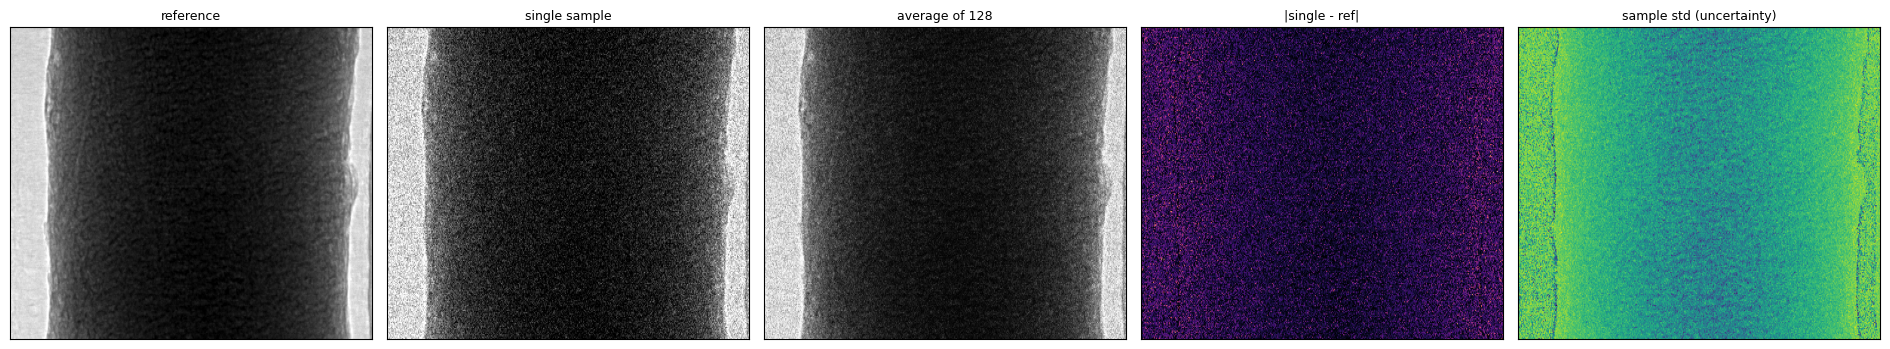

single sample : PSNR 19.75
average of 128: PSNR 23.87  SSIM 0.416   (+4.12 dB over single)


In [12]:
lo, hi = NORM
i = 0
single = to_counts(samples[:, 0])[i]
avg16  = to_counts(samples.mean(dim=1))[i]
std16  = samples[i].std(dim=0)[0].detach().cpu().numpy()   # normalized-space std

fig, axes = plt.subplots(1, 5, figsize=(19, 3.6))
for ax, (ttl, im, kw) in zip(axes, [
    ('reference', mref_c[i], dict(cmap='gray', vmin=lo, vmax=hi)),
    ('single sample', single, dict(cmap='gray', vmin=lo, vmax=hi)),
    (f'average of {Bmax}', avg16, dict(cmap='gray', vmin=lo, vmax=hi)),
    ('|single - ref|', np.abs(single - mref_c[i]), dict(cmap='magma')),
    (f'sample std (uncertainty)', std16, dict(cmap='viridis'))]):
    ax.imshow(im, aspect='auto', **kw); ax.set_title(ttl, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

ps, _ = scores(to_counts(samples[:, 0]), mref_c)
pa, sa = scores(to_counts(samples.mean(dim=1)), mref_c)
print(f'single sample : PSNR {ps:.2f}')
print(f'average of {Bmax:2d}: PSNR {pa:.2f}  SSIM {sa:.3f}   (+{pa - ps:.2f} dB over single)')

## 8. Posterior mean from single-shot `pred_x0` (the MMSE denoiser)

The one-shot `pred_x0` is this model's strongest denoiser (the ancestral DDIM loop reconverges
to the noisy input because the corrupted-central conditioning leaks it). Each `pred_x0` draw is
`E[x0 | x_t, y]` for a fresh diffusion-noise + blind-spot realisation, so **averaging many draws
approximates the posterior mean `E[x0 | y]`** — the true MMSE estimate. Here we pick the best
timestep, then crank the number of averaged samples up a lot.

In [13]:
from sdate.tr_diffusion.pipeline import pred_x0_ensemble

# Pick the best single-shot timestep on the eval batch (reuse the M=8 batch from section 7).
# Wide, dataset-agnostic net -- do NOT narrow this to a previous dataset's known-good band
# (wunderkerze ~410-430; asc_thixo ~600-625) since the optimum is dataset/checkpoint-dependent
# and a narrow grid can silently miss the true optimum on a new acquisition.
ts_grid = [100, 200, 300, 400, 500, 600, 700, 800, 900]
best_t, best_p = None, -1
for tv in ts_grid:
    g = torch.Generator(device=device).manual_seed(0)
    m1, _ = pred_x0_ensemble(model, mcentral, mcontext, timestep=tv, num_samples=1,
                             ratio=cfg['n2v_ratio'], window=cfg['n2v_window'], generator=g)
    p, _ = scores(to_counts(m1), mref_c)
    print(f'  t={tv:4d}: single-shot PSNR {p:.2f}')
    if p > best_p: best_p, best_t = p, tv
print('best single-shot timestep T* =', best_t, f'({best_p:.2f} dB)')

  t= 100: single-shot PSNR 22.57


  t= 200: single-shot PSNR 26.29


  t= 300: single-shot PSNR 28.97


  t= 400: single-shot PSNR 30.86


  t= 500: single-shot PSNR 31.57


  t= 600: single-shot PSNR 30.67


  t= 700: single-shot PSNR 27.83


  t= 800: single-shot PSNR 23.02


  t= 900: single-shot PSNR 17.54
best single-shot timestep T* = 500 (31.57 dB)


In [14]:
# Posterior mean: average B single-shot pred_x0 draws at T*, sweeping B up to a large count.
Bs = [4, 128, 256]
g = torch.Generator(device=device).manual_seed(2)
mean_big, samp_big = pred_x0_ensemble(
    model, mcentral, mcontext, timestep=best_t, num_samples=max(Bs),
    ratio=cfg['n2v_ratio'], window=cfg['n2v_window'], chunk_size=32, generator=g,
)  # samp_big: (M, 128, 1, H, W)

pm_psnr, pm_ssim = [], []
for B in Bs:
    avg_c = to_counts(samp_big[:, :B].mean(dim=1))
    pp, ss = scores(avg_c, mref_c); pm_psnr.append(pp); pm_ssim.append(ss)
    print(f'B={B:3d}:  posterior-mean PSNR {pp:5.2f}  SSIM {ss:.3f}')

single_p = scores(to_counts(samp_big[:, 0]), mref_c)[0]
noop_p = scores(min_c, mref_c)[0]
print(f'\nsingle-shot PSNR {single_p:.2f} | posterior-mean(128) {pm_psnr[-1]:.2f} '
      f'(+{pm_psnr[-1]-single_p:.2f} dB) | no-op {noop_p:.2f}')

B=  4:  posterior-mean PSNR 32.70  SSIM 0.786
B=128:  posterior-mean PSNR 33.03  SSIM 0.798


B=256:  posterior-mean PSNR 33.03  SSIM 0.798



single-shot PSNR 31.65 | posterior-mean(128) 33.03 (+1.38 dB) | no-op 19.07


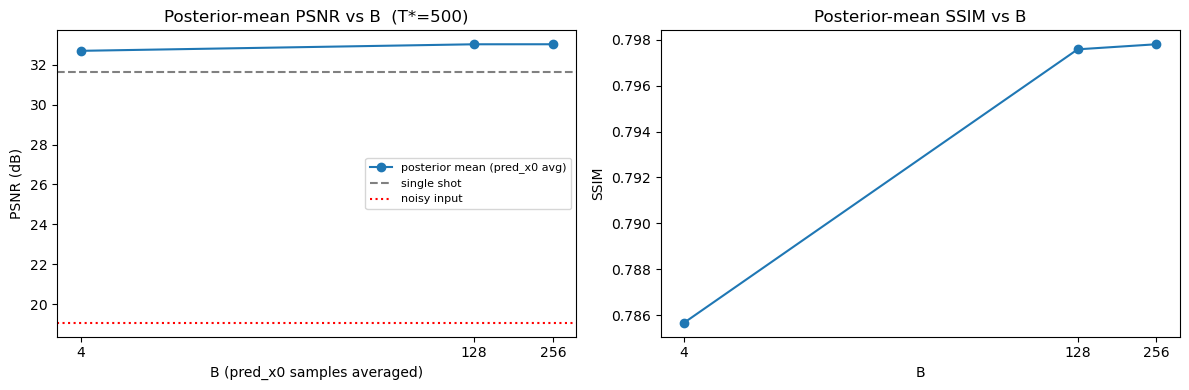

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(Bs, pm_psnr, 'o-', label='posterior mean (pred_x0 avg)')
ax[0].axhline(single_p, color='gray', ls='--', label='single shot')
ax[0].axhline(noop_p, color='r', ls=':', label='noisy input')
ax[0].set_xscale('log', base=2); ax[0].set_xticks(Bs); ax[0].set_xticklabels(Bs)
ax[0].set_xlabel('B (pred_x0 samples averaged)'); ax[0].set_ylabel('PSNR (dB)')
ax[0].set_title(f'Posterior-mean PSNR vs B  (T*={best_t})'); ax[0].legend(fontsize=8)
ax[1].plot(Bs, pm_ssim, 'o-'); ax[1].set_xscale('log', base=2)
ax[1].set_xticks(Bs); ax[1].set_xticklabels(Bs)
ax[1].set_xlabel('B'); ax[1].set_ylabel('SSIM'); ax[1].set_title('Posterior-mean SSIM vs B')
plt.tight_layout(); plt.show()

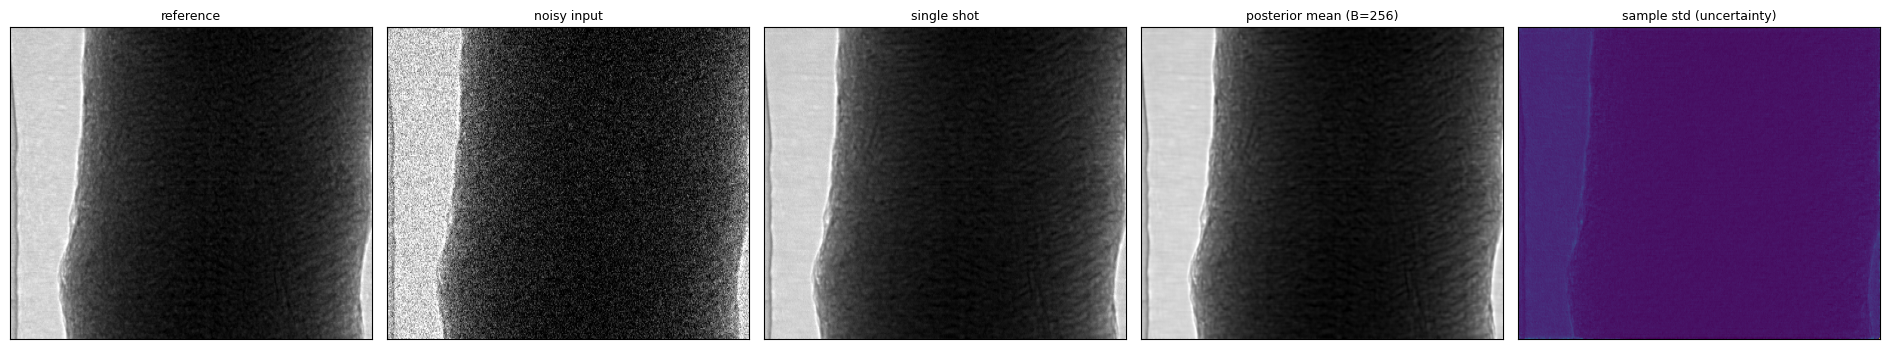

In [16]:
lo, hi = NORM
i = 2
single = to_counts(samp_big[:, 0])[i]
postmean = to_counts(samp_big.mean(dim=1))[i]
unc = samp_big[i].std(dim=0)[0].detach().cpu().numpy()
fig, axes = plt.subplots(1, 5, figsize=(19, 3.6))
for ax, (ttl, im, kw) in zip(axes, [
    ('reference', mref_c[i], dict(cmap='gray', vmin=lo, vmax=hi)),
    ('noisy input', min_c[i], dict(cmap='gray', vmin=lo, vmax=hi)),
    ('single shot', single, dict(cmap='gray', vmin=lo, vmax=hi)),
    (f'posterior mean (B={max(Bs)})', postmean, dict(cmap='gray', vmin=lo, vmax=hi)),
    ('sample std (uncertainty)', unc, dict(cmap='viridis'))]):
    ax.imshow(im, aspect='auto', **kw); ax.set_title(ttl, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 9. Short refinement trajectories — interval + step-count sweep

Between single-shot `pred_x0` and full ancestral sampling lies a **short DDIM refinement**:
noise the measurement to `t_start`, run a few steps down to `t_end`, read `pred_x0` at `t_end`.
Hypothesis: a few steps beat single-shot, but going all the way to 0 is counterproductive
(the conditioning reconverges to the noisy input). We sweep several `(t_start -> t_end, steps)`
configs and, for each, report both a single trajectory (B=1) and the posterior mean over B=16
trajectories — directly comparable to the single-shot posterior mean from section 8.

In [17]:
from sdate.tr_diffusion.pipeline import partial_diffusion, pred_x0_ensemble

T = best_t  # best single-shot timestep from section 8 (~500)
B_PM = 16   # posterior-mean samples per config

# (t_start, t_end, num_steps, label)
configs = [
    (T,       T,       1,  'single-shot (ref)'),
    (T,       T-100,   10, ''),
    (T,       T-100,   20, ''),
    (T+100,   T-100,   10, ''),
    (T+100,   T-100,   20, ''),
    (T,       T-200,   20, ''),
    (T+150,   T-250,   20, ''),
    (T,       0,       20, 'full-ish (to 0)'),
]

rows = []
for t0, t1, ns, label in configs:
    g = torch.Generator(device=device).manual_seed(3)
    if t0 == t1:  # single-shot reference
        mean, samp = pred_x0_ensemble(model, mcentral, mcontext, timestep=t0, num_samples=B_PM,
                                      ratio=cfg['n2v_ratio'], window=cfg['n2v_window'], generator=g)
    else:
        mean, samp = partial_diffusion(model, mcentral, mcontext, t_start=t0, t_end=t1, num_steps=ns,
                                       num_samples=B_PM, ratio=cfg['n2v_ratio'], window=cfg['n2v_window'],
                                       chunk_size=32, generator=g)
    p1, _  = scores(to_counts(samp[:, 0]), mref_c)          # single trajectory
    ppm, spm = scores(to_counts(mean), mref_c)              # posterior mean (B=16)
    rows.append((f'{t0}->{t1}', ns, p1, ppm, spm, label))
    print(f'  {t0:4d}->{t1:<4d} steps={ns:2d}  B1 PSNR {p1:5.2f}  |  B{B_PM} PSNR {ppm:5.2f}  SSIM {spm:.3f}  {label}')

noop = scores(min_c, mref_c)[0]
print(f'\nno-op (noisy input) PSNR {noop:.2f}')

   500->500  steps= 1  B1 PSNR 31.73  |  B16 PSNR 32.94  SSIM 0.795  single-shot (ref)


   500->400  steps=10  B1 PSNR 30.50  |  B16 PSNR 32.96  SSIM 0.795  


   500->400  steps=20  B1 PSNR 30.50  |  B16 PSNR 32.99  SSIM 0.795  


   600->400  steps=10  B1 PSNR 29.92  |  B16 PSNR 32.83  SSIM 0.793  


   600->400  steps=20  B1 PSNR 29.92  |  B16 PSNR 32.91  SSIM 0.793  


   500->300  steps=20  B1 PSNR 28.59  |  B16 PSNR 32.78  SSIM 0.787  


   650->250  steps=20  B1 PSNR 26.78  |  B16 PSNR 32.43  SSIM 0.775  


   500->0    steps=20  B1 PSNR 19.64  |  B16 PSNR 28.92  SSIM 0.611  full-ish (to 0)

no-op (noisy input) PSNR 19.07


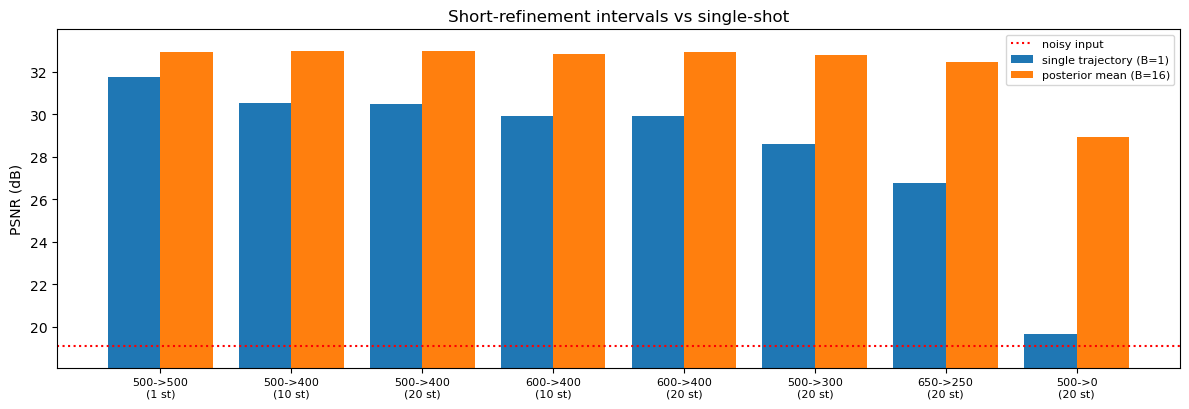

In [18]:
import numpy as np
labels = [f'{r[0]}\n({r[1]} st)' for r in rows]
b1  = [r[2] for r in rows]
bpm = [r[3] for r in rows]
x = np.arange(len(rows))
fig, ax = plt.subplots(figsize=(12, 4.2))
ax.bar(x-0.2, b1, 0.4, label='single trajectory (B=1)')
ax.bar(x+0.2, bpm, 0.4, label=f'posterior mean (B={B_PM})')
ax.axhline(noop, color='r', ls=':', label='noisy input')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('PSNR (dB)'); ax.set_title('Short-refinement intervals vs single-shot')
ax.set_ylim(min(noop, min(b1))-1, max(bpm)+1); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 10. Fine sweep of the 400–500 band

The single-shot sweep (section 8) was coarse (steps of 100) and section 9 showed the useful
refinement lives inside `[400, 500]`. Here we (a) finely sweep the single-shot timestep across
`t = 400..500`, and (b) test short refinements confined to that band, all as posterior means
over B=16 draws (the deployable metric).

In [19]:
# (a) Fine single-shot sweep, centred on the coarse-sweep best_t (+/-100), posterior mean B=16.
B_PM = 16
fine_ts = list(range(max(50, best_t - 100), min(950, best_t + 100) + 1, 10))
fs_psnr, fs_ssim = [], []
for tv in fine_ts:
    g = torch.Generator(device=device).manual_seed(4)
    mean, _ = pred_x0_ensemble(model, mcentral, mcontext, timestep=tv, num_samples=B_PM,
                               ratio=cfg['n2v_ratio'], window=cfg['n2v_window'], generator=g)
    pp, ss = scores(to_counts(mean), mref_c); fs_psnr.append(pp); fs_ssim.append(ss)
    print(f'  t={tv:4d}: B{B_PM} PSNR {pp:5.2f}  SSIM {ss:.3f}')
best_i = int(np.argmax(fs_psnr)); T_FINE = fine_ts[best_i]
print(f'\nbest single-shot in band: t={T_FINE}  PSNR {fs_psnr[best_i]:.2f}  SSIM {fs_ssim[best_i]:.3f}')

  t= 400: B16 PSNR 33.03  SSIM 0.797


  t= 410: B16 PSNR 33.03  SSIM 0.797


  t= 420: B16 PSNR 33.04  SSIM 0.797


  t= 430: B16 PSNR 33.02  SSIM 0.796


  t= 440: B16 PSNR 33.03  SSIM 0.797


...

  t= 560: B16 PSNR 32.71  SSIM 0.788


  t= 570: B16 PSNR 32.66  SSIM 0.787


  t= 580: B16 PSNR 32.58  SSIM 0.785


  t= 590: B16 PSNR 32.51  SSIM 0.784


  t= 600: B16 PSNR 32.44  SSIM 0.781

best single-shot in band: t=420  PSNR 33.04  SSIM 0.797


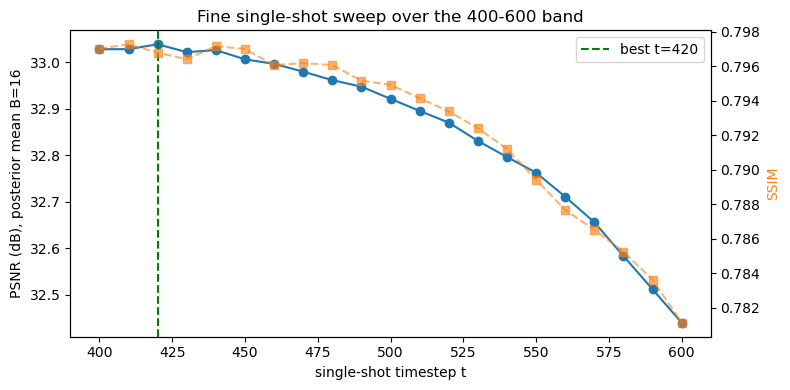

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(fine_ts, fs_psnr, 'o-')
ax.axvline(T_FINE, color='g', ls='--', label=f'best t={T_FINE}')
ax.set_xlabel('single-shot timestep t'); ax.set_ylabel(f'PSNR (dB), posterior mean B={B_PM}')
ax.set_title(f'Fine single-shot sweep over the {fine_ts[0]}-{fine_ts[-1]} band'); ax.legend()
ax2 = ax.twinx(); ax2.plot(fine_ts, fs_ssim, 's--', color='C1', alpha=0.6); ax2.set_ylabel('SSIM', color='C1')
plt.tight_layout(); plt.show()

In [21]:
# (b) Short refinements confined to the fine-swept band, relative to T_FINE, posterior mean B=16.
_hi, _lo = fine_ts[-1], fine_ts[0]
band_configs = [
    (_hi, _lo, 2), (_hi, _lo, 5), (_hi, _lo, 10), (_hi, _lo, 20), (_hi, _lo, 40),
    (_hi, T_FINE, 10), (T_FINE + (_hi - T_FINE) // 2, T_FINE - (T_FINE - _lo) // 2, 10), (T_FINE, _lo, 10),
]
print(f'single-shot best-in-band (t={T_FINE}): PSNR {fs_psnr[best_i]:.2f}  SSIM {fs_ssim[best_i]:.3f}\n')
for t0, t1, ns in band_configs:
    g = torch.Generator(device=device).manual_seed(4)
    mean, _ = partial_diffusion(model, mcentral, mcontext, t_start=t0, t_end=t1, num_steps=ns,
                                num_samples=B_PM, ratio=cfg['n2v_ratio'], window=cfg['n2v_window'],
                                chunk_size=32, generator=g)
    pp, ss = scores(to_counts(mean), mref_c)
    delta = pp - fs_psnr[best_i]
    print(f'  {t0}->{t1} steps={ns:2d}:  B{B_PM} PSNR {pp:5.2f}  SSIM {ss:.3f}   ({delta:+.2f} vs best single-shot)')

single-shot best-in-band (t=420): PSNR 33.04  SSIM 0.797



  600->400 steps= 2:  B16 PSNR 32.78  SSIM 0.793   (-0.25 vs best single-shot)


  600->400 steps= 5:  B16 PSNR 32.74  SSIM 0.793   (-0.30 vs best single-shot)


  600->400 steps=10:  B16 PSNR 32.81  SSIM 0.793   (-0.23 vs best single-shot)


  600->400 steps=20:  B16 PSNR 32.81  SSIM 0.793   (-0.23 vs best single-shot)


  600->400 steps=40:  B16 PSNR 32.84  SSIM 0.793   (-0.20 vs best single-shot)


  600->420 steps=10:  B16 PSNR 32.82  SSIM 0.793   (-0.22 vs best single-shot)


  510->410 steps=10:  B16 PSNR 32.95  SSIM 0.795   (-0.09 vs best single-shot)


  420->400 steps=10:  B16 PSNR 33.01  SSIM 0.797   (-0.03 vs best single-shot)


## 11. Definitive matched comparison (both models trained at dose 0.05)

Both the diffusion model and the baseline UNet are now trained at **dose 0.05** on identical
data / noise / context / conditioning-dropout, and evaluated on the same held-out batch at the
settled recipe: diffusion = single-shot `pred_x0` at the fine-swept `T*` and its posterior mean
(B=64); baseline = its natural single pass, plus a fair mask-averaged variant.

In [22]:
T_STAR = T_FINE if 'T_FINE' in globals() else best_t
B_FINAL = 64
print(f'diffusion cfg dose={cfg["extra_noise_dose"]} | baseline ckpt={BASELINE_CKPT.name} | T*={T_STAR}')

g = torch.Generator(device=device).manual_seed(5)
pm_mean, pm_samp = pred_x0_ensemble(model, mcentral, mcontext, timestep=T_STAR, num_samples=B_FINAL,
                                    ratio=cfg['n2v_ratio'], window=cfg['n2v_window'],
                                    chunk_size=32, generator=g)
diff_ss_c = to_counts(pm_samp[:, 0])     # diffusion single-shot
diff_pm_c = to_counts(pm_mean)           # diffusion posterior mean (B=64)

base_1_c = base_avg_c = None
if baseline is not None:
    base_1_c = to_counts(denoise_frames_baseline(baseline, mcentral, mcontext))
    stk = torch.stack([denoise_frames_baseline(baseline, mcentral, mcontext) for _ in range(16)])
    base_avg_c = to_counts(stk.mean(dim=0))

def line(name, c):
    p, s = scores(c, mref_c); print(f'{name:32s} {p:7.2f} {s:8.3f}')
print(f'{"method":32s} {"PSNR":>7s} {"SSIM":>8s}')
print('-'*50)
line('noisy input (no-op)', min_c)
if base_1_c is not None:
    line('baseline UNet (1 pass)', base_1_c)
    line('baseline UNet (avg 16 masks)', base_avg_c)
line(f'diffusion single-shot (t={T_STAR})', diff_ss_c)
line(f'diffusion posterior mean (B={B_FINAL})', diff_pm_c)

diffusion cfg dose=0.05 | baseline ckpt=tr_denoise_baseline_ag10_dose005.pt | T*=420


method                              PSNR     SSIM
--------------------------------------------------
noisy input (no-op)                19.07    0.200
baseline UNet (1 pass)             34.44    0.862
baseline UNet (avg 16 masks)       34.44    0.862
diffusion single-shot (t=420)      31.28    0.728
diffusion posterior mean (B=64)    33.15    0.801


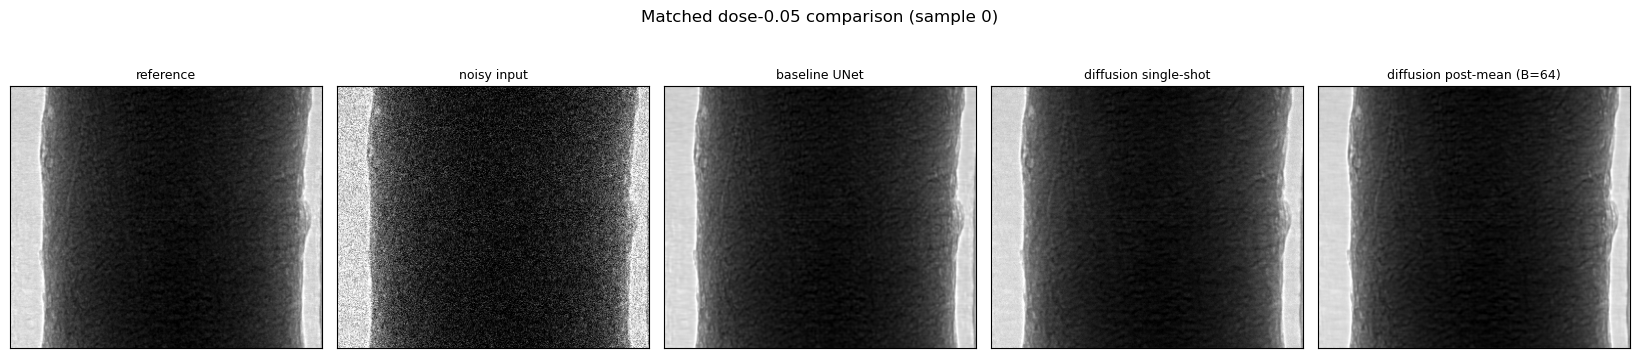

In [23]:
lo, hi = NORM
i = 0
panels = [('reference', mref_c[i]), ('noisy input', min_c[i])]
if base_1_c is not None: panels.append(('baseline UNet', base_1_c[i]))
panels += [('diffusion single-shot', diff_ss_c[i]),
           (f'diffusion post-mean (B={B_FINAL})', diff_pm_c[i])]
fig, axes = plt.subplots(1, len(panels), figsize=(3.3*len(panels), 3.4))
for ax, (ttl, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray', vmin=lo, vmax=hi, aspect='auto')
    ax.set_title(ttl, fontsize=9); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Matched dose-0.05 comparison (sample 0)', y=1.04)
plt.tight_layout(); plt.show()